# 3장 실습 — VLA 이전의 정책: ACT 와 Diffusion Policy

**대응 이론** 3장 「VLA 이전의 정책」 · **실행 등급 A** (CPU / Colab 무료 티어, 전체 약 3분)

VLA 는 빈 자리에서 나오지 않았다. 2023년 무렵 로봇 조작 학습에는 이미 잘 작동하는 정책 계열이 둘 있었고, VLA 는 그 위에 비전-언어 모델을 얹은 것에 가깝다.

- **ACT** (Action Chunking with Transformers) — 트랜스포머로 액션 **청크**를 한 번에 내고, CVAE 잠재변수로 시연의 다양성을 흡수한다
- **Diffusion Policy** — 액션 청크를 잡음에서 **점진적으로 복원**해 여러 갈래의 정답을 표현한다 (이 노트북에서는 같은 계보에서 구현이 가장 단순한 **플로 매칭** 형태로 쓴다 — 차이는 6장에서 다룬다)

이 노트북에서는 둘을 **평범한 회귀와 같은 조건에서** 겨루게 한다. 그리고 이 장에서 가장 중요한 것은 성능 숫자가 아니라 **그 성능을 어떤 지표가 보여 주고 어떤 지표가 가리는가**다.

1. 두 갈래로 갈리는 과제
2. 세 정책을 같은 예산으로
3. 지표가 가리는 것
4. CVAE 의 잠재변수가 흡수한 것
5. VLA 가 물려받은 것

In [2]:
%matplotlib inline
import os, time, math
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(os.cpu_count() or 2)

RED, GREY, PINK = "#e32c24", "#c8c8c8", "#f6c9c6"
print("torch", torch.__version__)

torch 2.9.1


## 1. 두 갈래로 갈리는 과제

과제는 단순하다. 왼쪽에서 출발해 오른쪽 목표로 가되 가운데 장애물을 피한다. **위로 돌아도 되고 아래로 돌아도 된다** — 둘 다 옳다.

시연은 두 갈래가 반씩 섞여 있다. 2장에서 본 관절 공간의 다봉성과 달리 이번에는 **과제 자체가 다봉**이라 표현을 바꿔서 없앨 수 없다.

정책은 한 번에 **16스텝 청크**를 낸다. 이것이 ACT 가 도입한 단위이고, 7장에서 그 효과를 따로 잰다.

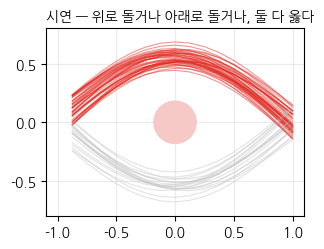

In [3]:
H = 16                                        # 청크 길이
def demo(n, seed):
    r = np.random.default_rng(seed); S = []; A = []; M = []
    for _ in range(n):
        s = np.array([-1.0, r.uniform(-.15, .15)], np.float32)
        g = np.array([ 1.0, r.uniform(-.15, .15)], np.float32)
        side = r.choice([-1, 1]); M.append(0 if side < 0 else 1)
        t = np.linspace(0, 1, H + 1)[1:]
        xs = s[0] + (g[0] - s[0]) * t
        ys = s[1] + (g[1] - s[1]) * t + side * 0.55 * np.sin(np.pi * t)
        S.append(np.concatenate([s, g])); A.append(np.stack([xs, ys], 1).astype(np.float32) - s)
    return torch.tensor(np.stack(S)), torch.tensor(np.stack(A)), np.array(M)

X, A, M = demo(4000, 0); Xte, Ate, Mte = demo(600, 7)

def both_modes(Xc):
    out = []
    t = np.linspace(0, 1, H + 1)[1:]
    s = Xc[:, :2].numpy(); g = Xc[:, 2:].numpy()
    for side in (-1, 1):
        xs = s[:, :1] + (g[:, :1] - s[:, :1]) * t[None]
        ys = s[:, 1:2] + (g[:, 1:2] - s[:, 1:2]) * t[None] + side * 0.55 * np.sin(np.pi * t)[None]
        out.append(torch.tensor(np.stack([xs, ys], 2).astype(np.float32)) - Xc[:, None, :2])
    return out
L, R = both_modes(Xte)

fig, ax = plt.subplots(figsize=(6.2, 2.6))
for i in range(60):
    tr = (A[i] + X[i, :2]).numpy()
    ax.plot(tr[:, 0], tr[:, 1], color=RED if M[i] else GREY, lw=.8, alpha=.5)
ax.add_patch(plt.Circle((0, 0), .18, color=PINK, zorder=3))
ax.set_aspect("equal"); ax.set_xlim(-1.1, 1.1); ax.set_ylim(-.8, .8); ax.grid(alpha=.25)
ax.set_title("시연 — 위로 돌거나 아래로 돌거나, 둘 다 옳다", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 2. 세 정책을 같은 예산으로

세 가지를 만든다. 은닉 폭과 학습 스텝을 비슷하게 맞춘다.

- **회귀** — 조건을 받아 청크를 바로 낸다
- **ACT 풍 CVAE** — 시연 청크를 잠재 z 로 압축하는 인코더와, 조건 + z 로 청크를 복원하는 디코더. 추론 때는 z 를 사전분포에서 뽑는다
- **플로 매칭 정책** — 잡음에서 청크로 가는 흐름장을 배우고, 추론 때 여러 스텝에 걸쳐 적분한다. 확산 정책과 같은 계보이며 적분 경로가 직선이라 구현이 간단하다

In [4]:
class Reg(nn.Module):
    def __init__(s, h=256):
        super().__init__()
        s.f = nn.Sequential(nn.Linear(4, h), nn.GELU(), nn.Linear(h, h), nn.GELU(), nn.Linear(h, H*2))
    def forward(s, x): return s.f(x).view(-1, H, 2)

class CVAE(nn.Module):
    def __init__(s, zd=2, h=256):
        super().__init__(); s.zd = zd
        s.enc = nn.Sequential(nn.Linear(4 + H*2, h), nn.GELU(), nn.Linear(h, h), nn.GELU(), nn.Linear(h, 2*zd))
        s.dec = nn.Sequential(nn.Linear(4 + zd, h), nn.GELU(), nn.Linear(h, h), nn.GELU(), nn.Linear(h, H*2))
    def encode(s, x, a): return s.enc(torch.cat([x, a.flatten(1)], 1)).chunk(2, -1)
    def forward(s, x, a):
        mu, lv = s.encode(x, a); z = mu + torch.randn_like(mu) * (0.5*lv).exp()
        return s.dec(torch.cat([x, z], 1)).view(-1, H, 2), mu, lv
    def sample(s, x):
        return s.dec(torch.cat([x, torch.randn(len(x), s.zd)], 1)).view(-1, H, 2)

class Diff(nn.Module):
    def __init__(s, h=256):
        super().__init__()
        s.f = nn.Sequential(nn.Linear(4 + H*2 + 1, h), nn.GELU(), nn.Linear(h, h), nn.GELU(), nn.Linear(h, H*2))
    def forward(s, x, a, t): return s.f(torch.cat([x, a.flatten(1), t], 1)).view(-1, H, 2)

def _opt(m, lr, steps):
    o = torch.optim.AdamW(m.parameters(), lr, weight_decay=1e-4)
    return o, torch.optim.lr_scheduler.OneCycleLR(o, lr, steps, pct_start=.15)

def train_reg(steps=3000, lr=2e-3):
    torch.manual_seed(0); m = Reg(); opt, sch = _opt(m, lr, steps); g = torch.Generator().manual_seed(1)
    for i in range(steps):
        idx = torch.randint(0, len(X), (256,), generator=g)
        loss = F.mse_loss(m(X[idx]), A[idx]); opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    return m

def train_cvae(steps=3000, lr=2e-3, beta=1e-3):
    torch.manual_seed(0); m = CVAE(); opt, sch = _opt(m, lr, steps); g = torch.Generator().manual_seed(1)
    for i in range(steps):
        idx = torch.randint(0, len(X), (256,), generator=g)
        rec, mu, lv = m(X[idx], A[idx])
        kl = (-0.5 * (1 + lv - mu.pow(2) - lv.exp()).sum(1)).mean()
        loss = F.mse_loss(rec, A[idx]) + beta * kl
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    return m

def train_diff(steps=4000, lr=2e-3):
    torch.manual_seed(0); m = Diff(); opt, sch = _opt(m, lr, steps); g = torch.Generator().manual_seed(1)
    for i in range(steps):
        idx = torch.randint(0, len(X), (256,), generator=g)
        a0 = A[idx]; t = torch.rand(len(idx), 1, generator=g); noise = torch.randn_like(a0)
        at = (1 - t[:, :, None]) * noise + t[:, :, None] * a0
        loss = F.mse_loss(m(X[idx], at, t), a0 - noise)          # 흐름장(속도) 회귀
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    return m

@torch.no_grad()
def diff_sample(m, x, steps=10):
    a = torch.randn(len(x), H, 2)
    for i in range(steps):
        a = a + m(x, a, torch.full((len(x), 1), i / steps)) / steps
    return a

def side_of(tr): return np.sign(tr[:, H//2, 1].numpy())
def hit(tr):     return (tr[:, H//2-2:H//2+2, 1].abs().min(1).values.numpy() < 0.18)
def nearest(tr): return torch.minimum(torch.norm(tr-L, dim=2).mean(1), torch.norm(tr-R, dim=2).mean(1)).mean().item()

t0 = time.time()
mr, mc, mdf = train_reg(), train_cvae(), train_diff()
print(f"학습 {time.time()-t0:.0f}s")
samples = {}
print(f"\n  {'정책':<16}{'위:아래':>10}{'장애물 통과':>12}{'추론 ms':>10}")
print("  " + "-" * 50)
for nm, fn in [("회귀", lambda: mr(Xte)), ("ACT 풍 CVAE", lambda: mc.sample(Xte)), ("플로 매칭 정책", lambda: diff_sample(mdf, Xte))]:
    t0 = time.perf_counter()
    with torch.no_grad(): p = fn()
    ms = (time.perf_counter() - t0) / len(Xte) * 1000
    samples[nm] = p; s = side_of(p)
    print(f"  {nm:<16}{f'{(s>0).mean():.0%}:{(s<0).mean():.0%}':>10}{hit(p).mean():>12.0%}{ms:>10.4f}")

학습 13s

  정책                    위:아래      장애물 통과     추론 ms
  --------------------------------------------------
  회귀                 39%:61%        100%    0.0008
  ACT 풍 CVAE         51%:49%          9%    0.0010
  플로 매칭 정책           48%:52%          4%    0.0084


회귀는 **100% 장애물을 통과한다.** 두 갈래의 평균이 정확히 장애물 한복판이기 때문이다. CVAE 는 9%, 플로 매칭은 4% 다.

그림으로 보면 분명하다.

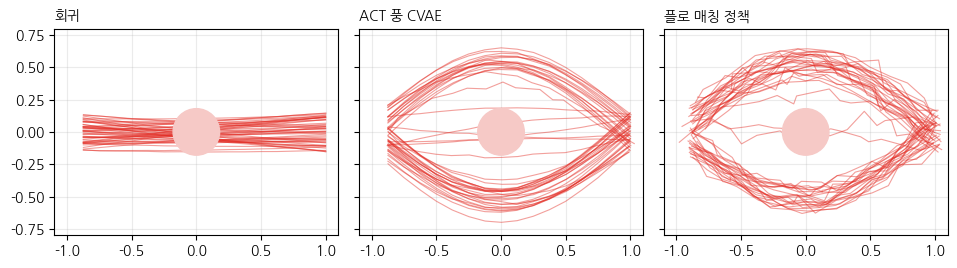

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(9.6, 2.6), sharey=True)
for ax, (nm, p) in zip(axes, samples.items()):
    for i in range(50):
        tr = (p[i] + Xte[i, :2]).numpy()
        ax.plot(tr[:, 0], tr[:, 1], color=RED, lw=.8, alpha=.45)
    ax.add_patch(plt.Circle((0, 0), .18, color=PINK, zorder=3))
    ax.set_aspect("equal"); ax.set_xlim(-1.1, 1.1); ax.set_ylim(-.8, .8)
    ax.grid(alpha=.25); ax.set_title(nm, fontsize=10, loc="left")
plt.tight_layout(); plt.show()

## 3. 지표가 가리는 것

이제 이 장에서 가장 중요한 부분이다. 세 정책을 **평범한 방식으로 채점하면** 어떻게 보이는가.

가장 흔한 채점법은 예측 청크와 **그 시연의 정답 청크** 사이의 거리를 재는 것이다. 검증 손실이 정확히 그것이다.

  정책                      해당 시연과의 거리         가까운 갈래와의 거리      장애물 통과
  --------------------------------------------------------------------
  회귀                          0.3496              0.3399        100%
  ACT 풍 CVAE                  0.3579              0.0505          9%
  플로 매칭 정책                    0.3662              0.0533          4%


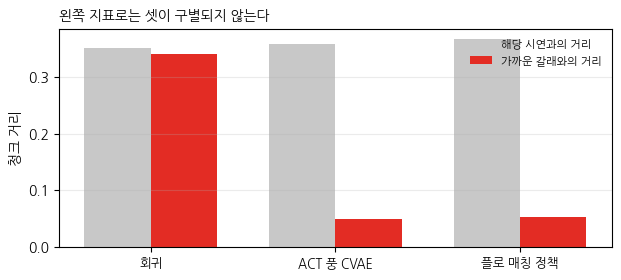

In [6]:
print(f"  {'정책':<16}{'해당 시연과의 거리':>18}{'가까운 갈래와의 거리':>20}{'장애물 통과':>12}")
print("  " + "-" * 68)
for nm, p in samples.items():
    print(f"  {nm:<16}{torch.norm(p-Ate, dim=2).mean():>18.4f}{nearest(p):>20.4f}{hit(p).mean():>12.0%}")

fig, ax = plt.subplots(figsize=(6.4, 2.9))
x = np.arange(3); w = .36
ax.bar(x - w/2, [torch.norm(p-Ate, dim=2).mean().item() for p in samples.values()], w,
       color=GREY, label="해당 시연과의 거리")
ax.bar(x + w/2, [nearest(p) for p in samples.values()], w, color=RED, label="가까운 갈래와의 거리")
ax.set_xticks(x); ax.set_xticklabels(list(samples), fontsize=9)
ax.set_ylabel("청크 거리"); ax.legend(fontsize=8, frameon=False); ax.grid(alpha=.25, axis="y")
ax.set_title("왼쪽 지표로는 셋이 구별되지 않는다", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 4. CVAE 의 잠재변수가 흡수한 것

ACT 의 CVAE 는 무엇을 하고 있는가. 학습할 때 인코더는 **시연 청크를 보고** 잠재 z 를 만든다. 그 z 에 무엇이 담기는지 직접 본다.

  아래로 돈 시연  z 평균 (+1.02, +0.01)   n=287
  위로 돈 시연    z 평균 (-1.04, -0.00)   n=313

  두 무리 중심 간격 2.06 / 전체 표준편차 0.52 = 4.0 배


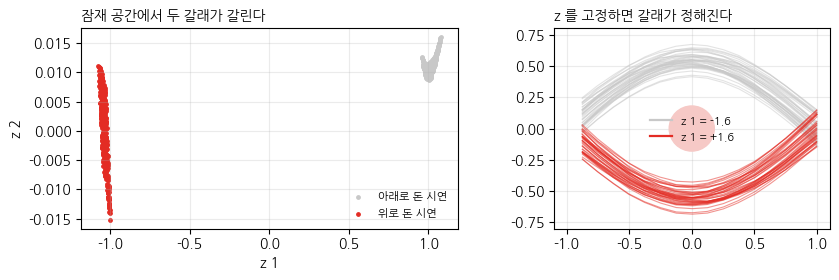

In [7]:
with torch.no_grad(): mu, _ = mc.encode(Xte, Ate)
mu = mu.numpy()
c0, c1 = mu[Mte == 0].mean(0), mu[Mte == 1].mean(0)
gap = np.linalg.norm(c0 - c1); spread = mu.std(0).mean()
print(f"  아래로 돈 시연  z 평균 ({c0[0]:+.2f}, {c0[1]:+.2f})   n={(Mte==0).sum()}")
print(f"  위로 돈 시연    z 평균 ({c1[0]:+.2f}, {c1[1]:+.2f})   n={(Mte==1).sum()}")
print(f"\n  두 무리 중심 간격 {gap:.2f} / 전체 표준편차 {spread:.2f} = {gap/spread:.1f} 배")

fig, axes = plt.subplots(1, 2, figsize=(9.0, 2.9))
axes[0].scatter(mu[Mte==0, 0], mu[Mte==0, 1], s=6, color=GREY, label="아래로 돈 시연")
axes[0].scatter(mu[Mte==1, 0], mu[Mte==1, 1], s=6, color=RED, label="위로 돈 시연")
axes[0].set_xlabel("z 1"); axes[0].set_ylabel("z 2"); axes[0].legend(fontsize=8, frameon=False)
axes[0].grid(alpha=.25); axes[0].set_title("잠재 공간에서 두 갈래가 갈린다", loc="left", fontsize=10)
for zval, c, lbl in [(-1.6, GREY, "z 1 = -1.6"), (1.6, RED, "z 1 = +1.6")]:
    z = torch.zeros(40, 2); z[:, 0] = zval
    with torch.no_grad():
        p = mc.dec(torch.cat([Xte[:40], z], 1)).view(-1, H, 2)
    for i in range(40):
        tr = (p[i] + Xte[i, :2]).numpy()
        axes[1].plot(tr[:, 0], tr[:, 1], color=c, lw=.8, alpha=.5)
    axes[1].plot([], [], color=c, lw=1.6, label=lbl)
axes[1].add_patch(plt.Circle((0, 0), .18, color=PINK, zorder=3))
axes[1].set_aspect("equal"); axes[1].set_xlim(-1.1, 1.1); axes[1].set_ylim(-.8, .8)
axes[1].legend(fontsize=8, frameon=False); axes[1].grid(alpha=.25)
axes[1].set_title("z 를 고정하면 갈래가 정해진다", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

  추론 방식                         위:아래      장애물 통과         가까운 갈래와의 거리
  --------------------------------------------------------------------
  z 를 사전분포에서 뽑기              51%:49%          9%              0.0505
  z = 0 으로 고정                 8%:92%        100%              0.3058
  (참고) 회귀                    39%:61%        100%              0.3399


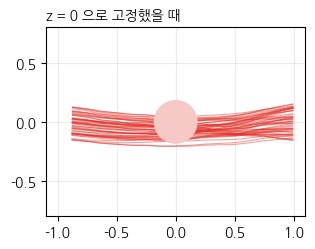

In [8]:
z0 = torch.zeros(len(Xte), mc.zd)
with torch.no_grad():
    p0 = mc.dec(torch.cat([Xte, z0], 1)).view(-1, H, 2)
print(f"  {'추론 방식':<24}{'위:아래':>10}{'장애물 통과':>12}{'가까운 갈래와의 거리':>20}")
print("  " + "-" * 68)
for nm, p in [("z 를 사전분포에서 뽑기", samples["ACT 풍 CVAE"]), ("z = 0 으로 고정", p0),
              ("(참고) 회귀", samples["회귀"])]:
    s_ = side_of(p)
    print(f"  {nm:<24}{f'{(s_>0).mean():.0%}:{(s_<0).mean():.0%}':>10}{hit(p).mean():>12.0%}{nearest(p):>20.4f}")

fig, ax = plt.subplots(figsize=(6.2, 2.6))
for i in range(50):
    tr = (p0[i] + Xte[i, :2]).numpy()
    ax.plot(tr[:, 0], tr[:, 1], color=RED, lw=.8, alpha=.45)
ax.add_patch(plt.Circle((0, 0), .18, color=PINK, zorder=3))
ax.set_aspect("equal"); ax.set_xlim(-1.1, 1.1); ax.set_ylim(-.8, .8); ax.grid(alpha=.25)
ax.set_title("z = 0 으로 고정했을 때", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 5. VLA 가 물려받은 것

정리하면 이 두 계열이 남긴 것은 셋이다.

- **청크** — 한 스텝이 아니라 여러 스텝을 한 번에 낸다. 7장에서 지연과 매끄러움에 미치는 효과를, 16장에서 제어 주파수를 사는 수단으로 다시 만난다
- **다봉 표현** — CVAE 든 확산·플로 매칭이든, 같은 조건에 여러 정답이 있다는 것을 표현한다. 6장의 플로 매칭이 이 계보의 현재 형태이고 파이제로 계열이 쓴다
- **트랜스포머 백본** — ACT 가 조작 정책에 트랜스포머를 정착시켰고, VLA 는 그 자리에 **사전학습된 비전-언어 모델**을 넣었다

VLA 가 새로 얹은 것은 하나다. **정책의 조건에 언어가 들어가고, 그 언어를 이해하는 부분이 웹 규모로 사전학습되어 있다는 것.** 1장에서 본 「인터페이스가 나르지 못하는 것」에 대한 답이 여기다.

대가도 적어 둔다. 청크 하나를 얻는 데 **순전파를 10번** 해야 하고, 측정된 추론 시간은 CVAE 의 **열 배 안팎**이었다 — 거의 정확히 적분 스텝 수만큼이다. 이런 마이크로 측정은 실행마다 흔들리므로, 숫자 자체보다 **스텝 수에 비례한다**는 구조를 기억하는 편이 낫다. 6장에서 적분 스텝 수와 정확도의 관계를, 16장에서 그 비용이 지연 예산에서 어떻게 보이는지 다룬다.

### 다음 장으로
2부에서는 그 「언어를 얹는다」가 구체적으로 무엇인지 — 세 개의 탑을 세우고, 액션을 토큰으로 자르거나 흐름으로 밀고, 시간과 기억을 붙이는 일 — 를 직접 만들며 본다.